<a href="https://colab.research.google.com/github/jeandirel/NLP/blob/main/pytorch_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ## Load pre-trained models in PyTorch, modify them to fit your dataset, and perform fine-tuning to make the most of the pre-trained knowledge

## This code loads the VGG16 model with pre-trained weights. You can now use this model directly on the same type of data (i.e., ImageNet-like images) that it was trained on. However, in most cases, you’ll want to adapt it to work with your own data,

**Chargement et inspection du modèle VGG16 pré‑entraîné**

In [ ]:
import torch
import torchvision.models as models

# Load pre-trained VGG16 model
model = models.vgg16(pretrained=True)
# Print the model architecture
print(model)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 228MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

* Since the original VGG16 model was trained to classify images into 1,000 classes (from ImageNet), we need to make a few adjustments to the model architecture.

* Common Modifications:
Changing the Output Layer: The number of output features (classes) in the final layer needs to match the number of classes in your dataset.
Modifying Pooling Layers: In some cases, the image size might not be compatible with the pooling layers in the original model, so you might need to modify these layers.

**Personnalisation du classifieur VGG16 pour 10 classes**

In [ ]:
import torch.nn as nn
# Replace the classifier of the VGG16 model
model.classifier[6] = nn.Linear(in_features=4096, out_features=10)
# Print the modified model
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**Gel des poids VGG16 sauf pour le classifieur**

In [ ]:
# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

This code snippet replaces the final layer of the VGG16 model (which originally outputs 1,000 classes for ImageNet) with a new linear layer that outputs 10 classes (for CIFAR-10).

The below code shows how you can freeze all the layers except the classifier. Now, only the classifier layers will be updated during training, making training much faster and computationally less expensive.

****Préparation du modèle VGG16 pour CIFAR‑10 : adaptation du classifieur et gel des autres couches**
**

In [ ]:
# Load the pre-trained VGG16 model
model = torchvision.models.vgg16(pretrained=True)
# Modify the classifier for CIFAR-10 (10 classes)
model.classifier[6] = nn.Linear(in_features=4096, out_features=10)
# Freeze all layers except the classifier
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

**Définition des transformations d’entrée (ToTensor + normalisation ImageNet)**


In [ ]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

* We are using PyTorch’s built-in torchvision.datasets to load the CIFAR-10 dataset.

* CIFAR-10  is an established computer-vision dataset used for object recognition. It is a subset of the 80 million tiny images dataset and consists of 60,000 32x32 color images containing one of 10 object classes, with 6000 images per class. It was collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton.


* We apply basic transformations like resizing and normalization.


**de CIFAR‑10 et configuration des DataLoaders**


In [ ]:
# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
# DataLoader for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:43<00:00, 3.95MB/s]


In [ ]:
# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**Boucle d’entraînement : fonction de perte Cross‑Entropy, optimiseur SGD et apprentissage sur 10 époques**


In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.classifier.parameters(), lr=0.001, momentum=0.9)
# Training loop
for epoch in range(10):  # Run for 10 epochs
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        print(running_loss/len(train_loader))
        #print(f'Epoch [{epoch+1}/10], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct / total:.2f}%’)
#### Step 4: E

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
0.3749466515944132
0.37576021101621104
0.3766287709669689
0.37752716891143634
0.3781788910517607
0.3791691905168621
0.38024912065709643
0.381364588580473
0.3820585222424144
0.3829320421075577
0.38349049925194373
0.3844243958782967
0.3852339095776648
0.38594786033910866
0.3866893347266995
0.3877704244135591
0.3888637880077752
0.3893661627074337
0.3900301281143637
0.39097189743195654
0.39154665065390987
0.39231302103270654
0.3930573530133118
0.39374170595270286
0.39437402944887995
0.3951700165524812
0.39592394129851893
0.39688056322467297
0.3977692190872129
0.398710575974201
0.39965245047646103
0.4003045405344585
0.4011677092374743
0.4020422157805289
0.40275221601928896
0.40360747475910674
0.4042935887032458
0.40525045194436826
0.4061542335145004
0.4068181964823657
0.40755957445067825
0.40817812157561406
0.40902528848946856
0.4099539550750152
0.4108624093596588
0.411500590193607
0.4122434777905569
0.41310493853

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 70.04%


Accuracy test : 70.04%


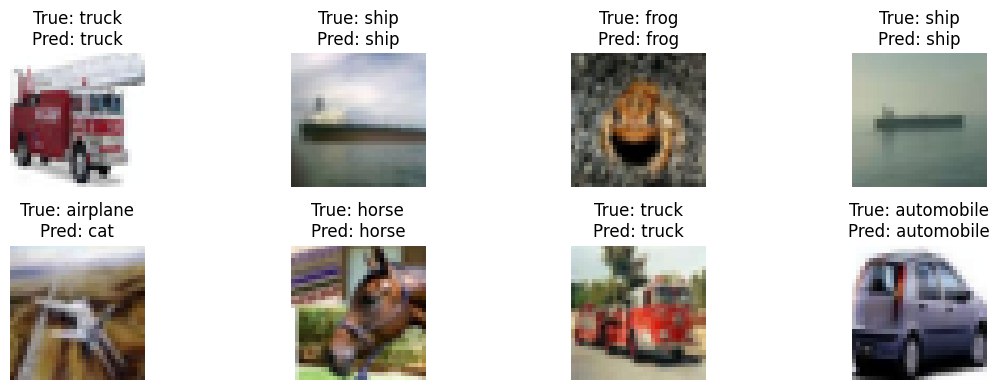

In [ ]:
# =======================  Inférence complète sur le jeu de test  =======================
import torch, torchvision
import matplotlib.pyplot as plt
import numpy as np

model.eval()                       # mode déploiement
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        logits = model(inputs)
        preds  = logits.argmax(1)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# Concatène tous les mini‑batches
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Précision globale
accuracy = (all_preds == all_labels).float().mean().item() * 100
print(f"Accuracy test : {accuracy:.2f}%")

# ----------------------------------------------------------
# Option : afficher 8 images aléatoires avec prédiction & label vrai
classes = train_dataset.classes        # ['airplane', 'automobile', …]
idxs = np.random.choice(len(test_dataset), 8, replace=False)

plt.figure(figsize=(12,4))
for i, idx in enumerate(idxs, 1):
    img, true_lbl = test_dataset[idx]
    pred_lbl = classes[all_preds[idx]]
    img = img.permute(1,2,0).numpy()              # CHW → HWC
    img = (img * np.array([0.229,0.224,0.225]) +  # dé‑normalise
           np.array([0.485,0.456,0.406]))
    img = np.clip(img, 0, 1)

    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(f"True: {classes[true_lbl]}\nPred: {pred_lbl}")
    plt.axis("off")
plt.tight_layout()
plt.show()
